<a href="https://colab.research.google.com/github/23424022/Pengolahan-Citra-Digital/blob/main/PCD_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

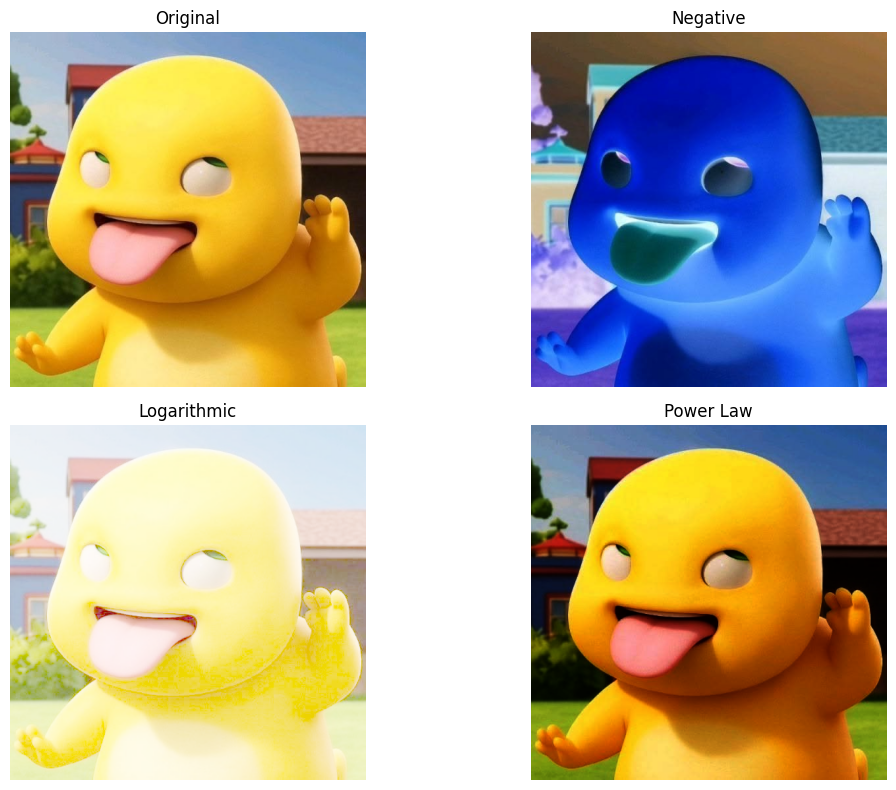

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv2.imread('/content/ecoliyebenziyo.jpg')

if img is None:
    print("Gambar tidak ditemukan")
    exit()

# Konversi BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ======================
# 1. Negative
# ======================
negative = 255 - img_rgb

# ======================
# 2. Logarithmic
# ======================
img_float = img_rgb.astype(np.float32)

c = 255 / np.log(1 + np.max(img_float))
log_img = c * np.log(1 + img_float)

log_img = np.clip(log_img, 0, 255)
log_img = log_img.astype(np.uint8)

# ======================
# 3. Power Law
# ======================
gamma = 2.0

img_norm = img_rgb.astype(np.float32) / 255.0
power = np.power(img_norm, gamma)

power = np.clip(power * 255, 0, 255)
power = power.astype(np.uint8)

# ======================
# Menampilkan gambar
# ======================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Negative")
plt.imshow(negative)
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Logarithmic")
plt.imshow(log_img)
plt.axis("off")

plt.subplot(2,2,4)
plt.title("Power Law")
plt.imshow(power)
plt.axis("off")

plt.tight_layout()
plt.show()